Project: SWEEP-Net (Spiking Weakly-supervised EEG Emotion Prototyping Network)


The Core Objective: To develop a highly energy-efficient, neuromorphic-ready Brain-Computer Interface (BCI) capable of topologically explainable emotion recognition, robust to both cross-session impedance shifts and cross-subject anatomical variance.

The Problem: Current deep learning BCIs suffer from severe "Session Gaps" (overfitting to daily impedance/noise) and lack spatial explainability (outputting a black-box integer instead of a biological heatmap). Furthermore, standard dense models are too power-hungry for wearable deployment.

Our Solution (Milestone 1 Focus): We propose a parameter-efficient (~807k) Atrous-MobileNet Encoder combined with a Bidirectional Temporal Shift Module (TSM). In this milestone, we demonstrate Phase 1: utilizing Supervised Contrastive Learning (SupCon) to project processed EEG signals into a session-invariant, biologically continuous semantic manifold (128D Hypersphere).

# Importing dependencies & Setting up constants

In [ ]:
%matplotlib inline

import yaml
import os
import torch
import torch.nn as nn
import umap
import numpy as np
import matplotlib.pyplot as plt

from src.snn_modeling.models.unet import SpikingResNetClassifier
from src.snn_modeling.utils.model_builder import build_model
from src.snn_modeling.utils.utils import seed_everything
from src.snn_modeling.dataloader.dataset import SWEEPDataset

from torch.utils.data import DataLoader
import wandb
from IPython.display import Image, display

In [3]:
CHECKPOINT_SUBJ = "checkpoint/subj1/"
CHECKPOINT_LOSO = "checkpoint/loso1/"
CONFIG = "config/config.yaml"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed_everything() # Seeds everything for reproducibility

# Training script

We engineered a custom 5D spatiotemporal encoder. It uses Depthwise-Pointwise convolutions to remain computationally "Lite" for future Spiking Neural Network (SNN) translation. We incorporate Atrous (Dilated) Convolutions in the deep stages to capture long-range neurological connectivity without losing spatial resolution, avoiding the standard "gridding artifact." For video processing, we bypass Conv3d or (2+1)D Convs using Bi-Directional (Offline) Temporal Shift Module trick by Lin et al. (2019)

- Experiment Definition: Can Supervised Contrastive Learning (SupCon) overcome idiosyncratic EEG noise and discover the universal biological signature of emotion?

- Setup: We conduct two distinct pre-training paradigms:
  - Intra-Subject (Subject 1 only): Train on Sessions 1 & 2, Test on Session 3.
  - Leave-One-Subject-Out (LOSO): Train on Subjects 2-15, Test on Subject 1.

We apply aggressive augmentations (FrequencyDropout, VideoTemporalMasking) to force the network to rely on topological shapes rather than specific frequencies or temporal artifacts.

The reason behind using MobileNet is as follows: while it is generally true that MobileNet would hit consistently lower accuracy than traditional dense ResNe(X)ts on ImageNet benchmarks, EEG Topologically Mapped videos or frames don't behave exactly like RGB images. Since each band (delta - gamma) have different frequency and meaning, just mixing them as usual and looking for "textures" (i.e. Gabor Filters) is not fruitful. Precisely, Delta waves usually convey larger power (due to inverse frequency correlation), producing larger "clouds," while Gamma waves manifest themselves as isolated, high-frequency & low-power spikes. Therefore, Separable Depthwise Convolutions would learn spatial topology of each band independently, with Pointwise Convolutions looking out for correlations across frequency bands.  Secondly, we deal with 9-10k samples per subject to train (~220k samples in general; not even near to 1.2 million high-resolution pictures). Since we aim to reconstruct feature maps from latent space at decoder-side, getting 4x4 or 2x2 maps (as what would usual ResNet backbones produce) is inadequate spatial resolution. In addition, it is generally desirable to have at least >128 channels for SupCon training so Projection Head would produce 128D vectors, which would require less stages/layers of usual ResNet. To combat this, we employ dilated/atrous convolutions that would allow MobileNet to have larger receptive field, have far less parameters and thus allow increasing stages/blocks within, and achieve comparatively higher resolution feature maps. While Deformable Convolutions also strikes appealing as they would help extracting non-square features, they do have additional convolutional regression head, which is additional parameters, and also this idea simply won't work with SNN directly as it would break bilinear interpolation.

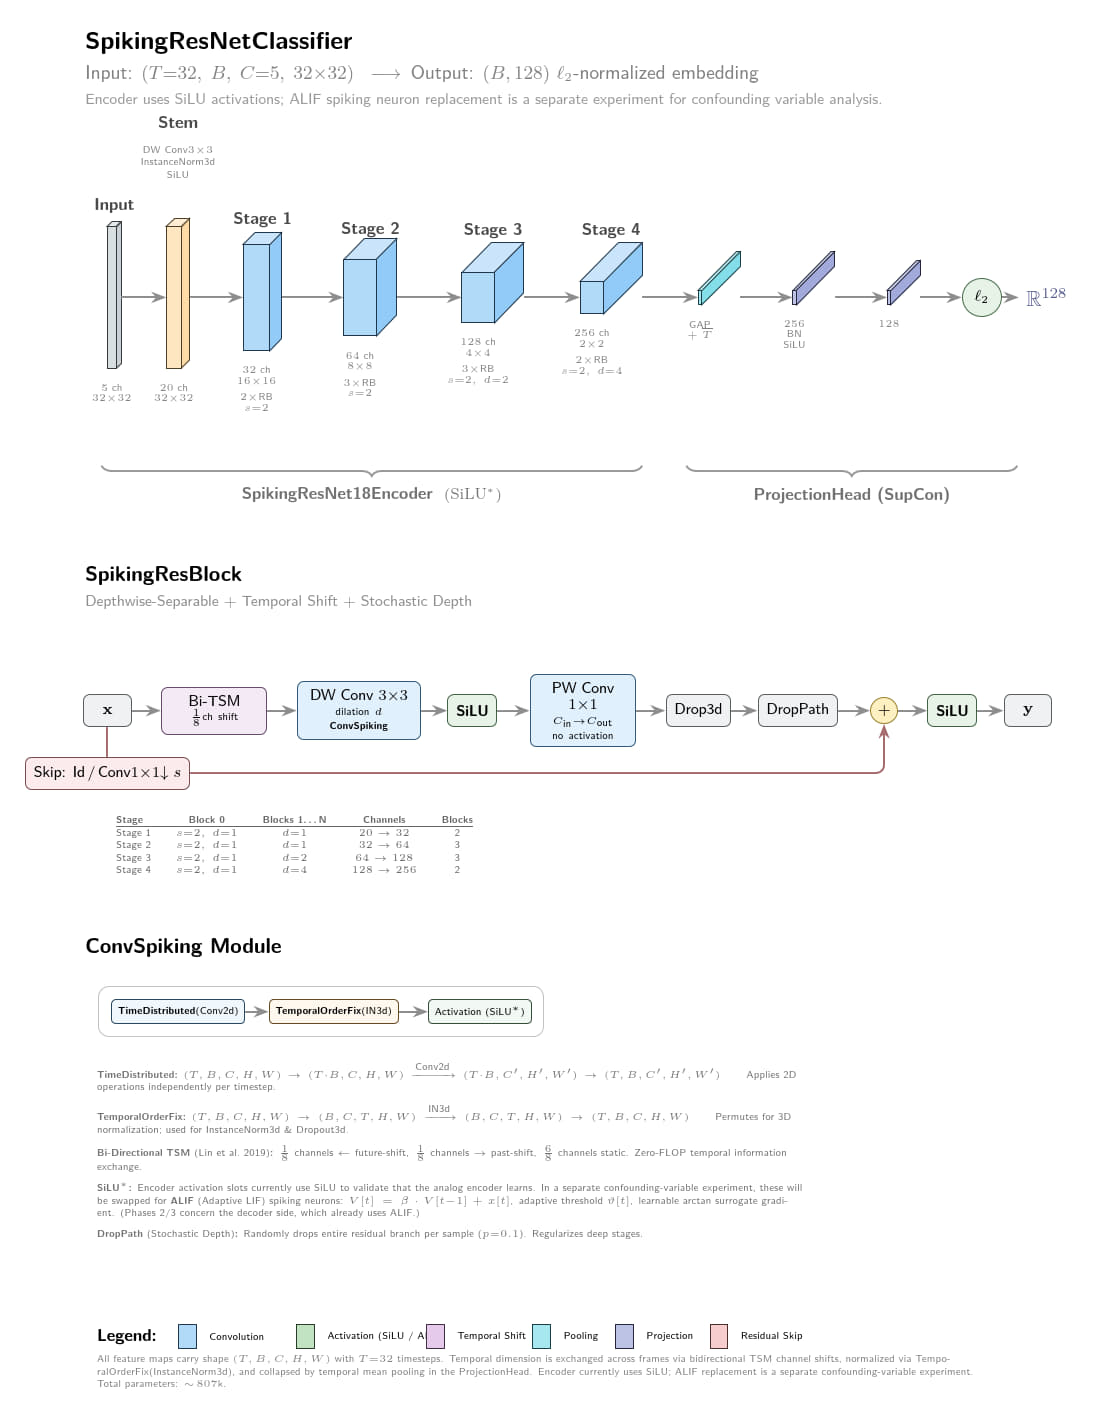

In [ ]:
display(Image(filename="./figures/arch.jpg"))

In [ ]:
!python main.py --config config/config.yaml --subj 1 --phase 1
!python main.py --config config/config.yaml --loso 1 --phase 1

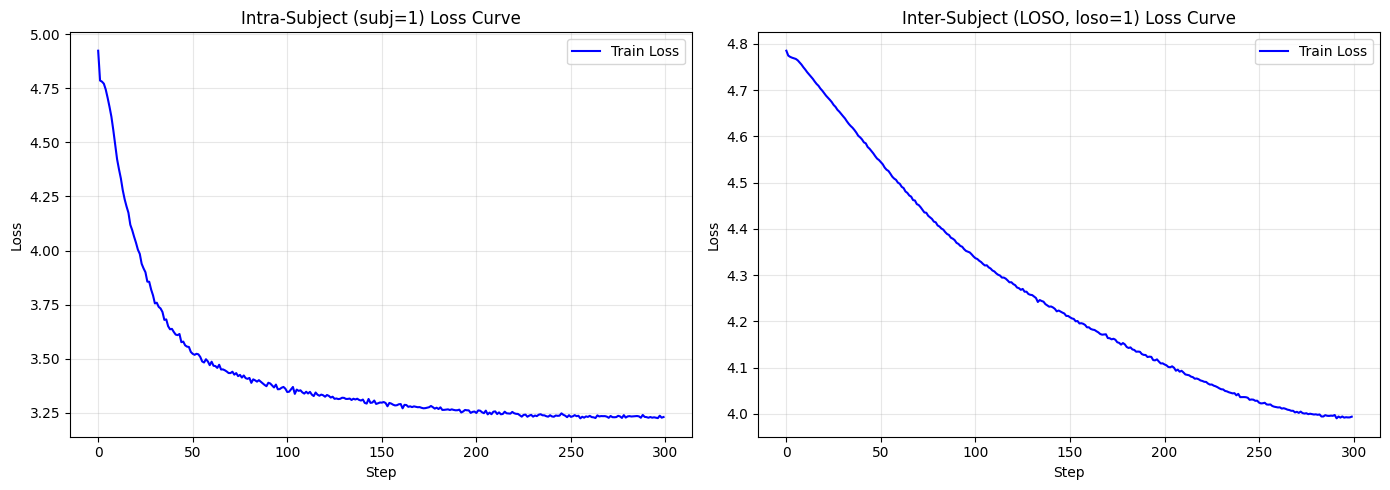

In [7]:

WANDB_ENTITY = "emammadli"
WANDB_PROJECT = "snn-encoding-showdown"

RUN_ID_SUBJ = "707fnud7"  # Run ID for intra-subject (subj=1)
RUN_ID_LOSO = "i45qpuq0"  # Run ID for inter-subject (LOSO, loso=1)

api = wandb.Api()

def fetch_loss_history(entity, project, run_id):
    run = api.run(f"{entity}/{project}/{run_id}")
    
    history = run.history(keys=["Phase1/Train/Loss"], pandas=True)
    return history

# Fetch loss data
subj_history = fetch_loss_history(WANDB_ENTITY, WANDB_PROJECT, RUN_ID_SUBJ)
loso_history = fetch_loss_history(WANDB_ENTITY, WANDB_PROJECT, RUN_ID_LOSO)

# Plot loss curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Intra-subject loss plot
ax1 = axes[0]

ax1.plot(subj_history['Phase1/Train/Loss'].dropna(), label='Train Loss', color='blue')

ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.set_title('Intra-Subject (subj=1) Loss Curve')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Inter-subject (LOSO) loss plot
ax2 = axes[1]
ax2.plot(loso_history['Phase1/Train/Loss'].dropna(), label='Train Loss', color='blue')

ax2.set_xlabel('Step')
ax2.set_ylabel('Loss')
ax2.set_title('Inter-Subject (LOSO, loso=1) Loss Curve')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Loading models from checkpoints

In [ ]:
with open(CONFIG, 'r') as file:
        config = yaml.safe_load(file)

In [ ]:
masks = torch.load(os.path.join(config['data']['dataset_path'],'masks.pt')).to(device)

In [ ]:
model_subj = build_model(config).to(device) # Intra-subject (subj=1) model
model_subj = SpikingResNetClassifier(
    encoder_backbone = model_subj.encoder,
    num_classes=config['model'].get('num_classes', 5)
).to(device)
checkpoint_subj = torch.load(CHECKPOINT_SUBJ, map_location=device)
print(f"Loaded checkpoint from {CHECKPOINT_SUBJ}.")

model_subj.load_state_dict(checkpoint_subj['model_state_dict'])

subj_set = SWEEPDataset(
                        config, 
                        split='val',
                        experiment=False,
                        subj=1,
                        prototypes=masks
                        )

In [ ]:
model_loso = build_model(config).to(device) # Inter-subject (LOSO, loso=1) model
model_loso = SpikingResNetClassifier(
    encoder_backbone = model_loso.encoder,
    num_classes=config['model'].get('num_classes', 5)
).to(device)
checkpoint_loso = torch.load(CHECKPOINT_LOSO, map_location=device)
print(f"Loaded checkpoint from {CHECKPOINT_LOSO}.")

model_loso.load_state_dict(checkpoint_loso['model_state_dict'])

loso_set = SWEEPDataset(
                        config, 
                        split='val',
                        experiment=False,
                        loso=1,
                        prototypes=masks
                        )

# Visualising Results via UMAP

In [ ]:

EMOTION_LABELS = {0: 'Disgust', 1: 'Fear', 2: 'Sad', 3: 'Neutral', 4: 'Happy'}
EMOTION_COLORS = ['#8B0000', '#800080', '#4169E1', '#808080', '#FFD700']  # Dark red, purple, blue, gray, gold

def visualize_results(model, dataloader, device, title="UMAP Visualization"):
    model.eval()
    all_feats = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = inputs.permute(1,0,2,3,4)
            feats, _ = model.encoder(inputs)
            feats = feats.mean(dim=[0,3,4])  # Global average pooling
            all_feats.append(feats.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_feats = np.concatenate(all_feats, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    
    # UMAP with 15 neighbors
    reducer = umap.UMAP(n_neighbors=15, random_state=42)
    embedding = reducer.fit_transform(all_feats)
    
    # Visualization with emotion labels
    plt.figure(figsize=(10, 8))
    for label_id, emotion_name in EMOTION_LABELS.items():
        mask = all_labels == label_id
        if mask.sum() > 0:
            plt.scatter(embedding[mask, 0], embedding[mask, 1], 
                       c=EMOTION_COLORS[label_id], label=emotion_name, 
                       alpha=0.7, s=10)
    
    plt.legend(title='Emotion', loc='best')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.title(title)
    plt.tight_layout()
    plt.show()
    
    return embedding, all_labels

In [ ]:
embedding_subj, labels_subj = visualize_results(
    model_subj, 
    DataLoader(subj_set, batch_size=64, shuffle=False, pin_memory=True), 
    device,
    title="Intra-Subject (subj=1) UMAP Visualization"
)

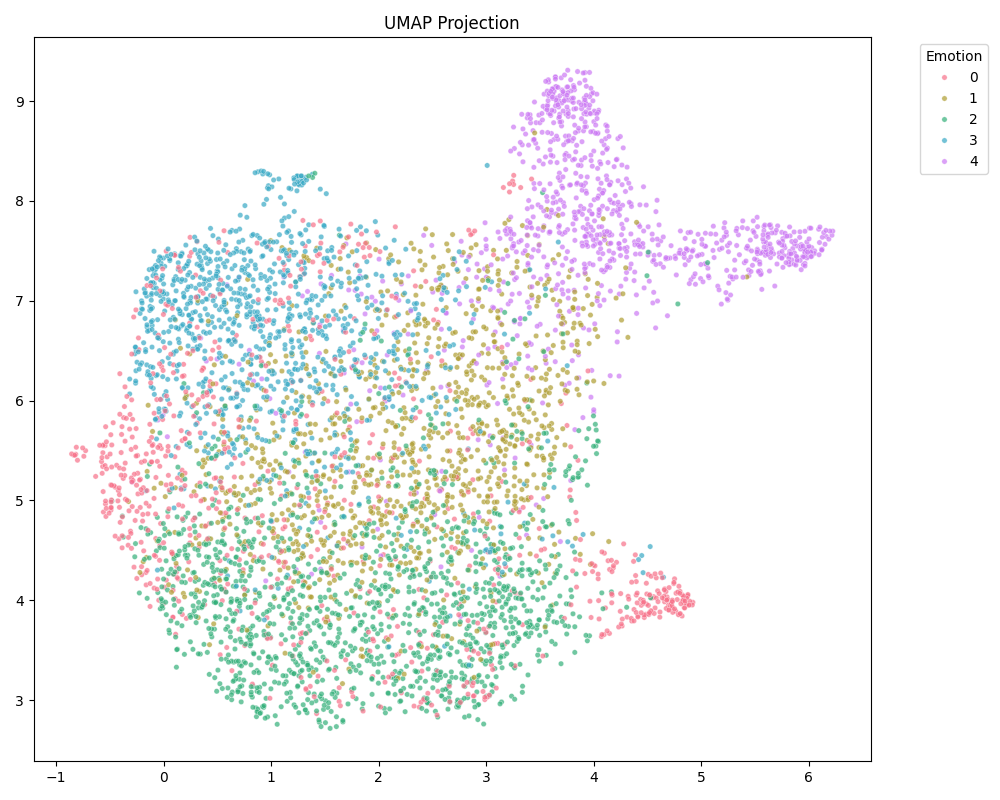

In [5]:
display(Image(filename="./figures/umap_subj1.png"))

In [ ]:
embedding_loso, labels_loso = visualize_results(
    model_loso, 
    DataLoader(loso_set, batch_size=64, shuffle=False, pin_memory=True), 
    device,
    title="Inter-Subject (LOSO, loso=1) UMAP Visualization"
)

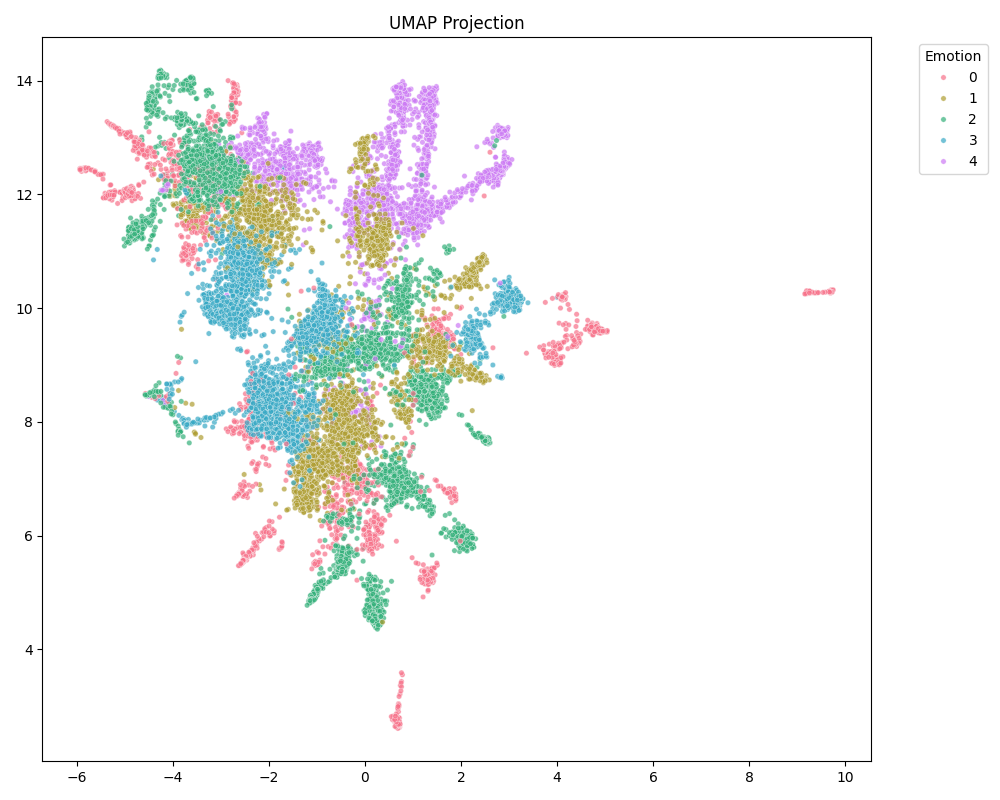

In [4]:
display(Image(filename="./figures/umap_loso1.png"))

# Milestone 2 & Beyond: Topologically-Aware Decoding

While Phase 1 successfully mapped the macro-biology, resolving the subtle micro-topological differences between Fear and Disgust requires transitioning to Phase 2 & Phase 3. UMAP projections of the LOSO SupCon embeddings reveal that emotions do not form monolithic, unimodal clusters. Instead, they form a highly non-linear, multimodal archipelago (e.g., Disgust occupies multiple distinct, non-overlapping regions). This visually demonstrates the necessity of our proposed non-linear Spiking U-Net and MIL aggregation, as standard linear classifiers are mathematically incapable of bounding such fragmented manifolds. 

Moving forward, we will:

 - ODConv (Li et al. 2022): It allows to learn multiple kernels weighted by light-weight multi-dimensional attention mechanism, boosting accuracy of lightweight models. Boosted MobileNet's top-5 accuracy up to 92.18%.

 - Attach the Spiking U-Net Decoder: We will use gated skip-connections to bypass the 128D bottleneck, utilizing high-resolution spatial maps to reconstruct biologically accurate 2D Ground Truth Z-Energy Masks. In light of being gated, these connections will also act as translators, bypassing the need to pick standardized spike modulation options. At later stages, we extract the memory (i.e. potentials themselves) to pass through finalizing stages and producing mask, in accordance with usual SNN-related documentations.

 - Density-Adaptive TopoMapper: To prevent spatial blurring in the dense frontal lobe, we are implementing a dynamically adaptive Gaussian RBF. Borrowing the "Perplexity" binary search algorithm from t-SNE, we will dynamically shrink the Gaussian variance (σ) in dense electrode regions, exponentially increasing spatial resolution for the U-Net.

 - Topological Contrastive Loss (Soft InfoNCE): We plan to modify the InfoNCE loss multiplier to inherently scale by (1 + dice_score). This "Topology-Aware Hard Negative Mining" will violently repel latent vectors whose Ground Truth spatial masks are highly identical (e.g., Fear and Disgust), forcing the Encoder to learn deeper, highly discriminative micro-features.

 - Multiple Instance Learning (MIL) & Global Context (GC, Cao et al.) Blocks: The brutal biological truth is that it is often impossible to discern distinct affective states (e.g., Fear vs. Disgust) from a single 1-second window. Furthermore, blindly assigning a global trial label to every 1-second slice mathematically forces Phase 1 Supervised Contrastive Learning (SupCon) to pull neutral anticipation and peak emotional shock into the exact same cluster, causing severe latent entanglement. However, processing a full 60-second 5D spatiotemporal tensor simultaneously will instantly exceed GPU memory limits. To solve this temporal and hardware paradox across all training phases, we propose:

   - (a) Spatial-Channel Weighting: Using GC blocks (SE-blocks + Non-Local) at deeper encoder stages to correctly weight the spatial topology of each 1-second micro-state.

   - (b) Phase 1 Bag-Level Contrastive Learning (WeakSupCon, Zhang et al. 2025): Instead of instance-level SupCon, we extract continuous "mini-bags" (e.g., 10-second chunks) from a trial. We employ MIL with a lightweight SwiGLU attention mechanism to dynamically up-weight peak emotional spikes and suppress neutral baseline windows. This aggregated bag-level embedding is passed directly to the Projection Head, allowing the InfoNCE loss to build indestructible clusters from true emotional prototypes without causing out-of-memory (OOM) errors.

   - (c) Phase 2/3 Mask Reconstruction: Ultimately, these SwiGLU-aggregated trial embeddings, combined with our gated skip-connections, are fed to the Spiking Decoder to reconstruct a biologically accurate, uniform 2D Ground Truth Z-Energy Mask that captures the full emotion dynamics of the session.

